# Cell type

In [ ]:
from functools import partial
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.plt import (
    plot_colormap, plot_line, set_ipynb_variable,
    get_ipynb_file_name, save_figure,
)
from lucifex.utils.npy_utils import as_index
from crocodil.theory.system_a import threshold_rayleigh
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

cell_opts = ('quadrilateral', 'right', 'right_left', 'left_right')
NX = 80
NY= 80
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 200)
dt_init = 1e-6
n_init = 10

Ra_thresh = threshold_rayleigh(SYSTEM_A_REFERENCE['aspect'], 1.0, NY, 2)
print(f"Ra = {SYSTEM_A_REFERENCE['Ra']} , Ra_thresh = {Ra_thresh}")

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=partial(as_grid_simulation, slc_func='::5', include=('c', 'cMinMax', 'uRMS', 'uMinMax')),
    link=True,
    max_nbytes=None,
    mmap_mode=None,
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    dt_Cu=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    dt_Cr=COURANT_REAC,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)(
    cell=cell_opts,
)

Ra = 1000.0 , Ra_thresh = 1800.0


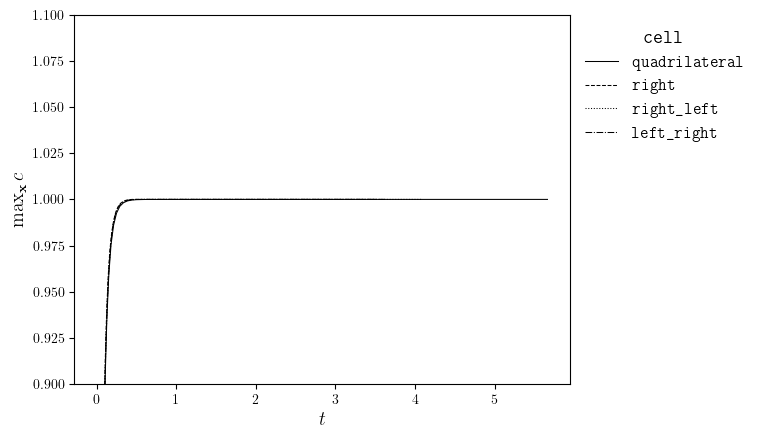

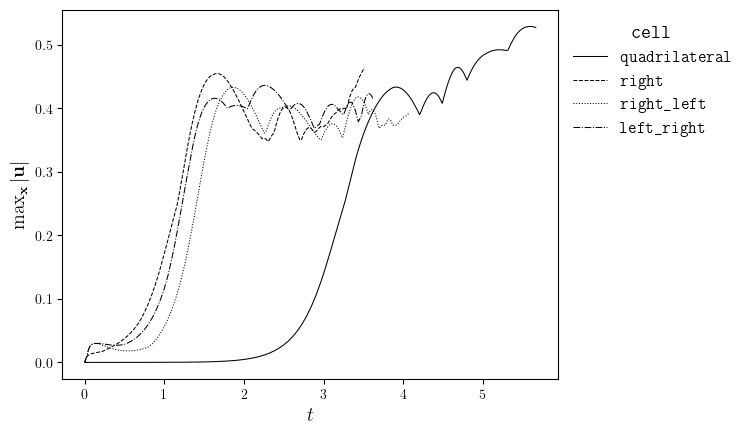

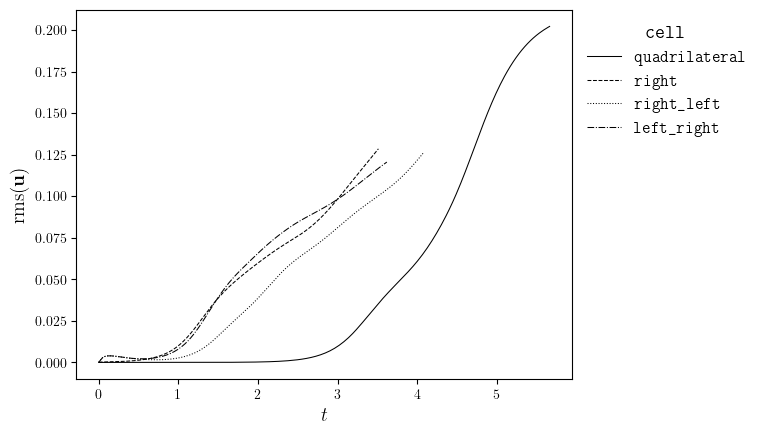

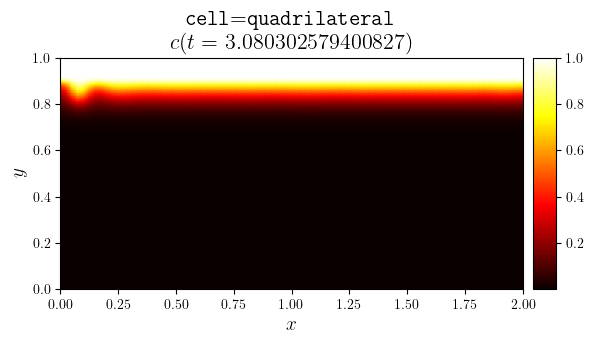

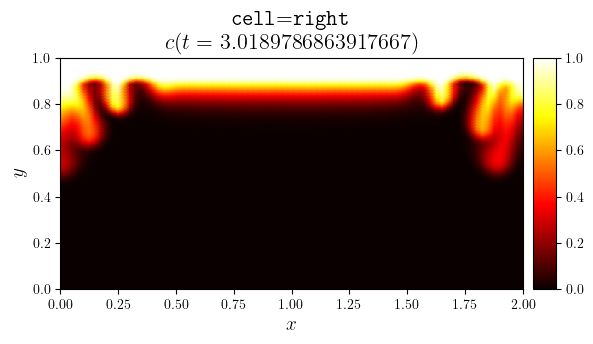

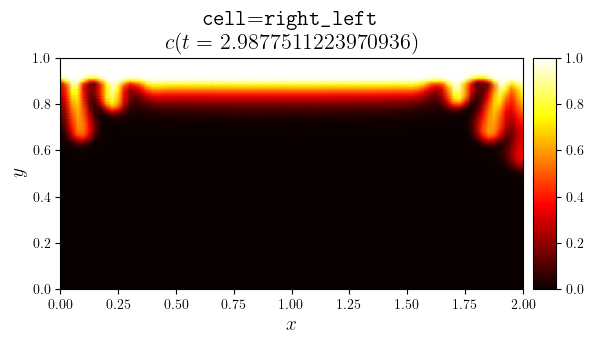

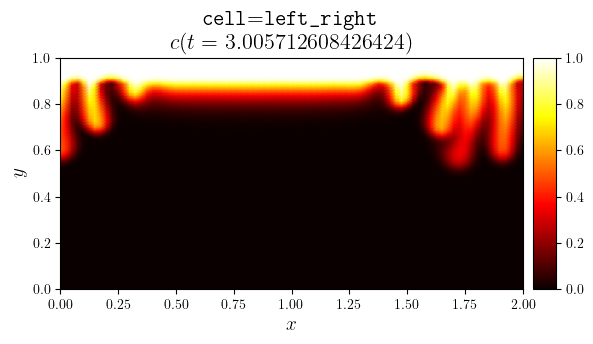

: 

In [ ]:
DIR_FIGS = f'./figures/{get_ipynb_file_name()}'

cMax_lines, uMax_lines, uRMS_lines, labels = [], [], [], []
legend_title = f'$\\texttt{{cell}}$'

cmap_t_target = 3.0
cmap_funcs, cmap_titles = [], []

for cell, sim in simulations.items():
    label = f'$\\texttt{{{cell}}}$'
    labels.append(label)
    cMinMax = sim['cMinMax']
    cMax = cMinMax.sub(1)
    cMax_lines.append((cMax.time_series, cMax.value_series))
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, cmap_t_target)
    cmap_funcs.append(c.series[time_index])
    cmap_titles.append(f'{legend_title}$ = ${label}\n$c(t={c.time_series[time_index]})$')

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=labels,
    legend_title=legend_title,
)

fig, ax = plot_line(
    cMax_lines,
    y_label='$\max_{\mathbf{x}} c$',
    y_lims=(0.9, 1.1),
    **line_kws,
)
if DIR_FIGS: save_fig('cMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uMax_lines,
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    **line_kws,
)
if DIR_FIGS: save_fig('uMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uRMS_lines,
    y_label='$\mathrm{rms}(\mathbf{u})$',
    **line_kws,
)
if DIR_FIGS: save_fig('uRMS(t)', DIR_FIGS, prefix=False)(fig)

for func, title in zip(cmap_funcs, cmap_titles): fig, ax = plot_colormap(func, title=title)